<a href="https://colab.research.google.com/github/harshitt018/Advance-Data-Science/blob/main/%20DCGAN%20(Deep%20Convolutional%20generative%20adversarial%20network).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip -q install kagglehub

import kagglehub

# Download dataset
path = kagglehub.dataset_download("andrewmvd/animal-faces")

print("Dataset Path:", path)

Resuming download from 69206016 bytes (660494739 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/andrewmvd/animal-faces/1.archive (69206016/729700755) bytes left.


100%|██████████| 696M/696M [00:41<00:00, 15.9MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/andrewmvd/animal-faces/versions/1


In [3]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    if len(files) > 0:
        print("Files:", len(files))
        break

/root/.cache/kagglehub/datasets/andrewmvd/animal-faces/versions/1
/root/.cache/kagglehub/datasets/andrewmvd/animal-faces/versions/1/afhq
/root/.cache/kagglehub/datasets/andrewmvd/animal-faces/versions/1/afhq/val
/root/.cache/kagglehub/datasets/andrewmvd/animal-faces/versions/1/afhq/val/dog
Files: 500


In [4]:
cat_path = f"{path}/afhq/train/cat"

import os
print("Total Cat Images:", len(os.listdir(cat_path)))
print("Sample Images:", os.listdir(cat_path)[:5])

Total Cat Images: 5153
Sample Images: ['pixabay_cat_001376.jpg', 'pixabay_cat_000596.jpg', 'pixabay_cat_004321.jpg', 'pixabay_cat_004606.jpg', 'pixabay_cat_002245.jpg']


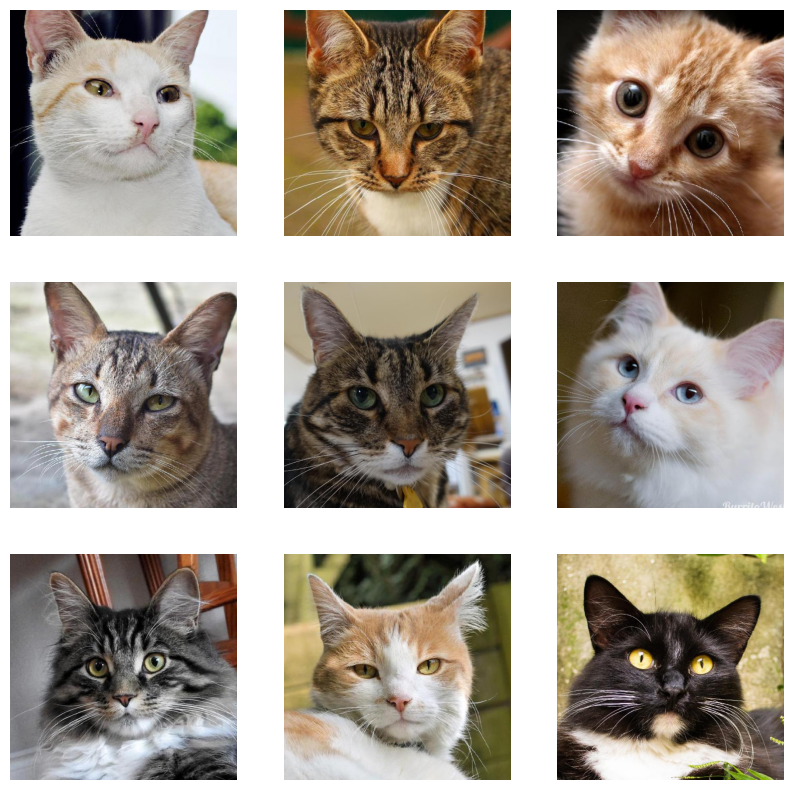

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

images = os.listdir(cat_path)

plt.figure(figsize=(10,10))

for i in range(9):
    img = Image.open(os.path.join(cat_path, random.choice(images)))

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

dataset = datasets.ImageFolder(
    root=f"{path}/afhq/train",
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print("Dataset Loaded Successfully!")
print("Total Images:", len(dataset))

Dataset Loaded Successfully!
Total Images: 14630


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 100
batch_size = 64
epochs = 50

print("Using:", device)

Using: cuda


In [8]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(
            nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1)

In [9]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("Models Ready!")

Models Ready!


In [10]:
for epoch in range(epochs):

    for real_images, _ in dataloader:

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size).to(device)
        fake_labels = torch.zeros(batch_size).to(device)

        # Train Discriminator
        optimizer_D.zero_grad()

        outputs = discriminator(real_images)
        d_loss_real = criterion(outputs, real_labels)

        noise = torch.randn(batch_size, 100, 1, 1).to(device)
        fake_images = generator(noise)

        outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()

        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()

        outputs = discriminator(fake_images)

        g_loss = criterion(outputs, real_labels)

        g_loss.backward()

        optimizer_G.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

Epoch [1/50] D Loss: 0.5456 G Loss: 5.2890
Epoch [2/50] D Loss: 0.9908 G Loss: 2.6379
Epoch [3/50] D Loss: 0.6642 G Loss: 2.7242
Epoch [4/50] D Loss: 0.5742 G Loss: 3.0623
Epoch [5/50] D Loss: 0.6622 G Loss: 4.4123
Epoch [6/50] D Loss: 1.0684 G Loss: 3.8669
Epoch [7/50] D Loss: 0.5286 G Loss: 4.3723
Epoch [8/50] D Loss: 0.3274 G Loss: 4.2810
Epoch [9/50] D Loss: 0.3300 G Loss: 3.1836
Epoch [10/50] D Loss: 0.5673 G Loss: 4.2066
Epoch [11/50] D Loss: 0.4599 G Loss: 4.1267
Epoch [12/50] D Loss: 0.7803 G Loss: 7.4507
Epoch [13/50] D Loss: 0.6035 G Loss: 2.9201
Epoch [14/50] D Loss: 0.1964 G Loss: 3.7475
Epoch [15/50] D Loss: 0.7369 G Loss: 6.2465
Epoch [16/50] D Loss: 0.5961 G Loss: 1.7709
Epoch [17/50] D Loss: 0.4161 G Loss: 3.3843
Epoch [18/50] D Loss: 0.3842 G Loss: 2.5872
Epoch [19/50] D Loss: 0.5738 G Loss: 6.8376
Epoch [20/50] D Loss: 0.6981 G Loss: 6.0234
Epoch [21/50] D Loss: 0.4317 G Loss: 3.6316
Epoch [22/50] D Loss: 0.3749 G Loss: 3.8966
Epoch [23/50] D Loss: 0.3349 G Loss: 3.08

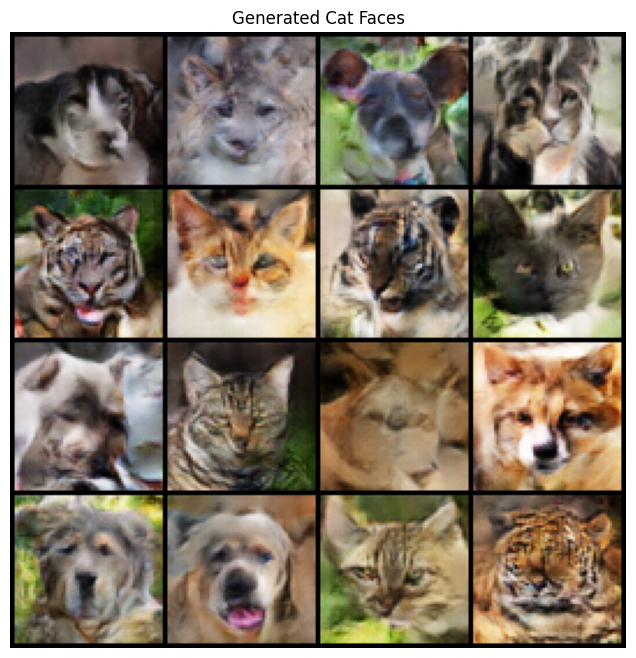

In [11]:
import torchvision
import matplotlib.pyplot as plt

generator.eval()

noise = torch.randn(16, 100, 1, 1).to(device)

with torch.no_grad():
    fake_images = generator(noise).cpu()

grid = torchvision.utils.make_grid(
    fake_images,
    nrow=4,
    normalize=True
)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.title("Generated Cat Faces")
plt.show()